### Decision Tree Intuition

In Decision tree we are trying to reach to decision by asking a series of binary questions. Each question reduces the search space as much as possible. Goal is to find the smallest set of questions that lead to right decision. We can say this is splitting process, we split and try to find the small decision and keep doing it for all splits.

Why we are using this? The reason is simple and interpretable. Ability to capture nonlinear and complex relationship between the feature and the response. There are some disadvantages, like Susceptible to overfitting, underpeformed.

We are going to use Position_Salaries.csv dataset (However this is very simple dataset, which is not ideal), Note: We don't have to apply feature scaling here because prediction from this regression resulting from successive split of the data from different of the tree.

#### When to avoid them?

1. Small Datasets 
2. Instability 
3. Limited Predictive Power
4. Imbalanced Dataset
5. Extrapolation
6. Continuous Prediction

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Implementation 1

In [1]:
data = {"age":["old","old","old","mid","mid","mid","mid","new","new","new"],
        "Competition":["yes","no","no","yes","yes","no","no","yes","no","no"],
        "type":["s/w","s/w","h/w","s/w","h/w","h/w","s/w","s/w","h/w","s/w"],
        "profit":["down","down","down","down","down","up","up","up","up","up"]}

Step 1: You need to choose a target attribute which you can choose based on your choice. This attribute also called class attribute. In this case we choose 'Profit'

Step 2: Now we need fing Information Gain (IG) which we can find with the help of formula

$IG = -\frac{P}{P + N} log_2(\frac{P}{P + N})  -\frac{N}{P + N} log_2(\frac{N}{P + N})$

Step 3: Now we need find out Entropy from the rest remaining three attribute which is eventually going to be root node of our Decision Tree.

$E(A) =  \displaystyle\sum_{i=1}^v \frac{P_i + N_i}{P + N} I(P_ iN_i)$

Step 4: Find out the Gain

$Gain = IG - E(A)$

Now we are going to find out Entropy of our selected attribute.Pick first 'Age' and make a table:

Age: Find out with the help of target attribute, how many total 'old' for target attribute 'down' and 'up' like that respectively.

|     | down | up |
|-----|------|----|
| old | 3    | 0  |
| mid | 2    | 2  |
| new | 0    | 3  |


Let's calculate, now put all in formula

In [4]:
dataset = pd.DataFrame(data)
dataset.head()

,age,Competition,type,profit
0,old,yes,s/w,down
1,old,no,s/w,down
2,old,no,h/w,down
3,mid,yes,s/w,down
4,mid,yes,h/w,down


In [6]:
import math

In [7]:
i_of_old = -(3/(3+0))*math.log2(3/(3+0))-(0/(3+0))* 0 # in python math.log2(0) raised the error so we consider putting 0 in this example

In [8]:
i_of_mid = -(2/(2+2))*math.log2(2/(2+2))-(2/(2+2))*math.log2(2/(2+2))

In [9]:
i_of_new = -(0/(0+3))* 0 -(3/(0+3))*math.log2(3/(0+3))

Now we need to multiply them with their respective probabilities. \
ex. old probability = number of times old appears / total data = 3 /10

In [10]:
E_of_age = (i_of_old * len(dataset[dataset["age"]=="old"])/len(dataset)) + (i_of_mid *  len(dataset[dataset["age"]=="mid"])/len(dataset)) + (i_of_new *  len(dataset[dataset["age"]=="new"])/len(dataset))
print(E_of_age)

0.4


Now we are going find out IG of target attribute

In [11]:
ig_of_profit = -(len(dataset[dataset["profit"] == "down"])/len(dataset) * math.log2(len(dataset[dataset["profit"] == "down"])/len(dataset)) + \
len(dataset[dataset["profit"] == "up"])/len(dataset) * math.log2(len(dataset[dataset["profit"] == "up"])/len(dataset)))

In [19]:
print(f"Initial Gain on Target Attribute is {ig_of_profit}")

Initial Gain on Target Attribute is 1.0


In [13]:
gain = ig_of_profit - E_of_age

In [14]:
print(gain) # this is the gain of attribute age

0.6


like wise other attributes IG can be calculated and they will following

In [15]:
ig_of_competition = 0.124
ig_of_type = 0.0

In [20]:
print(f"Gain of Competition: {ig_of_competition}")
print(f"Gain of Type: {ig_of_type}")
print(f"Gain of Age: {ig_of_profit - E_of_age}")
print(f"IG: {ig_of_profit}")

Gain of Competition: 0.124
Gain of Type: 0.0
Gain of Age: 0.6
IG: 1.0


Now we have all the final required output to build our decision tree. We need to find out which is the highest gain which is going to be root node. We can see that **age** has highest among all other three attribute, so age is our root node.

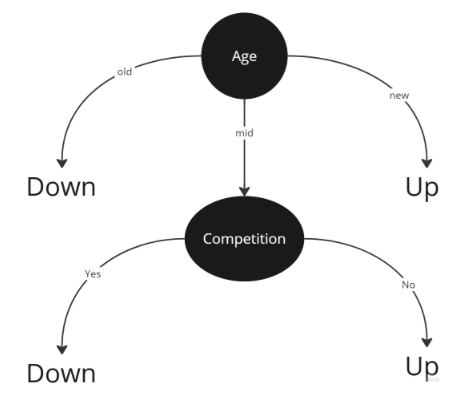

Let's understand this decision tree. We have already discussed, Age is going to be root node which has three unique types 'old', 'mid', & 'new'. old and new branch leaf node is Down and up because all old age target attributes is Down and new attribute is Up but situation is different with mid. If you observe your dataset, mid has both profit attribute values (Down & Up). It has mix, so we going to use next highest gain attribute which is Competition. Now same process continues as Age. So take mid of age, which has total four data and clear separation mapping with competition to profit attribute (yes -> Down, No -> Up). So when all target to one variant then we conclude that.

Now what we are going to type? Then answer is, we are not going to use type because we got our concluding decision and there is no mix variant. 

## Implementation 2

### Importing the dataset

In [3]:
data = pd.read_csv('Data/Position_Salaries.csv')
X = data.iloc[:, 1:-1].values
y = data.iloc[:, -1].values


### Training the Decision Tree Regression model on the whole dataset

In [6]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X, y)

DecisionTreeRegressor(random_state=0)

### Predicting a new result

In [7]:
regressor.predict([[6.5]])

array([150000.])

### Visualising the Decision Tree Regression results

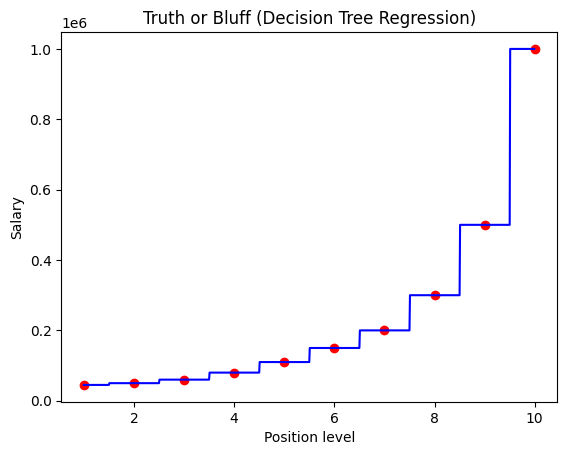

In [9]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

# Q&A


**Q. Which hyperparameter should be tuned to reduce overfitting in a decision tree model?**


> <span style="color:green">max_depth</span>: Limiting the maximum depth of the tree prevents it from growing too complex, which reduces the chance of overfitting. A deeper tree tends to overfit by capturing noise in the data.

**Q. Why do tree-based models not require standardization of data?**
> <p>Tree-based models are invariant to the scale of input features. The beauty of tree-based models lies in their flexibility. They simply decide, "Does this feature's value exceed a certain threshold?" It doesn’t matter if one feature is measured in meters and another in centimeters—they don’t need to be on the same scale for the model to work well.</p><p>Tree-based models, such as decision trees, random forests, and gradient boosting trees, do not require standardization (or normalization) of data because they are scale-invariant. This means that the magnitude of numerical values does not affect how the tree splits the data. Here’s why:<p style="font-weight:bold">1. Decision Rules are Based on Thresholds, Not Distance</p><p>Tree-based models split data using feature thresholds (e.g., "if feature $X > 5$, go left; otherwise, go right") rather than relying on distance-based calculations.</p><p>Unlike models such as logistic regression or k-nearest neighbors (KNN), which are sensitive to the scale of input features, trees only care about feature ranking and relative values.</p><p style="font-weight:bold">2. No Assumption of Gaussian Distribution</p><p>Many algorithms that require standardization (e.g., linear regression, neural networks, and SVM with RBF kernels) assume that the data follows a normal distribution for better convergence. Tree-based models, however, make no such assumption.</p><p style="font-weight:bold">3. Splitting Criteria Are Independent of Scale</p><p>Tree algorithms use splitting criteria like Gini impurity, entropy, or mean squared error (MSE), which are not affected by the absolute scale of numerical features.</p>

